In [142]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import emcee
from scipy.optimize import minimize
import math


In [143]:
data = 'true.dat'

#read the true value

true_val = [[float(i.strip().split()[j]) for j in range(len(i.strip().split()))] for i in open(data).readlines()] 
true_val = np.array(true_val)
    

#do a gaussian offset of all values
off_val = true_val + np.random.normal(0, 0.5, (len(true_val), 2))
with open("offset.dat", 'w') as f:
    [f.write(str(off_val[i,0]) + '\t' + str(off_val[i,1]) +  '\n') for i in range(len(off_val))] #write down the values
    f.close()

a_LS: 9.890 ± 0.234;  b_LS: 0.066840334 ± 0.000163691
a_true: 5.156;  b_true: 0.072727273
a compatibility: 20.20;	 b compatibilityL: 35.96


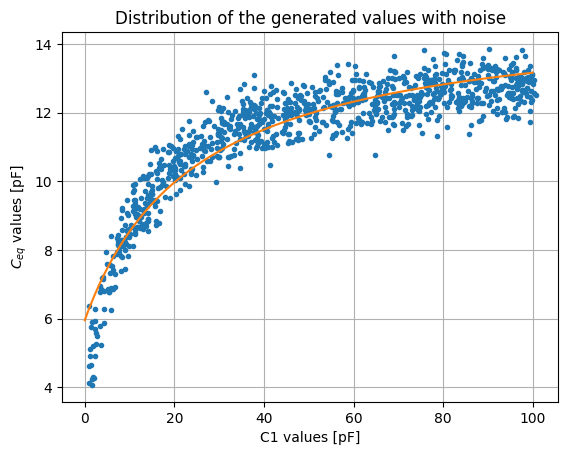

In [ ]:
def func(x, a, b):
    return 1/(1/(x+a)+b)

#true values
b_true= 1/(13.75)
a_true = 3.75/(1-b_true*3.75)
true_values = [a_true, b_true] #will be used later in MCMC

popt, pcov = curve_fit(func, off_val[:,0], off_val[:,1])
print(f"a_LS: %.3f \u00B1 %.3f;  b_LS: %.9f \u00B1 %.9f" % (popt[0], math.sqrt(pcov[0][0]), popt[1], math.sqrt(pcov[1][1])))
print(f"a_true: %.3f;  b_true: %.9f" % (a_true, b_true))
print(f"a compatibility: %.2f;\t b compatibilityL: %.2f" % (abs(a_true-popt[0])/math.sqrt(pcov[0][0]), abs(b_true-popt[1])/math.sqrt(pcov[1][1])))

#I do the plot below
x = np.linspace(0, 100, 2000)
y = func(x, popt[0], popt[1])

plt.plot(off_val[:,0], off_val[:,1], '.')
plt.plot(x, y)
plt.xlabel('C1 values [pF]')
plt.ylabel('$C_{eq}$ values [pF]')
plt.title("Distribution of the generated values with noise")
plt.grid()

In [ ]:
data = 'true.dat'

#read the true values
true_val = [[float(i.strip().split()[j]) for j in range(len(i.strip().split()))] for i in open(data).readlines()] 
true_val = np.array(true_val)

#I generate the error assiociated to each value
dCeq = abs(np.random.normal(0, 3, len(true_val)))
with open("errorbar.dat", 'w') as f:
    [f.write(str(true_val[i,1]) + '\t' + str(dCeq[i]) +  '\n') for i in range(len(off_val))] #write down the values
    f.close()

In [ ]:
#I create the new array with Ceq and dCeq 
data = 'errorbar.dat'

#read the true values
error_val = [[float(i.strip().split()[j]) for j in range(len(i.strip().split()))] for i in open(data).readlines()] 
error_val = np.array(error_val)

Success status: False
Desired error not necessarily achieved due to precision loss.
Maximum likelihood estimates:
m = 15.8676 (True: 5.1562)
q = 0.0686 (True: 0.0727)


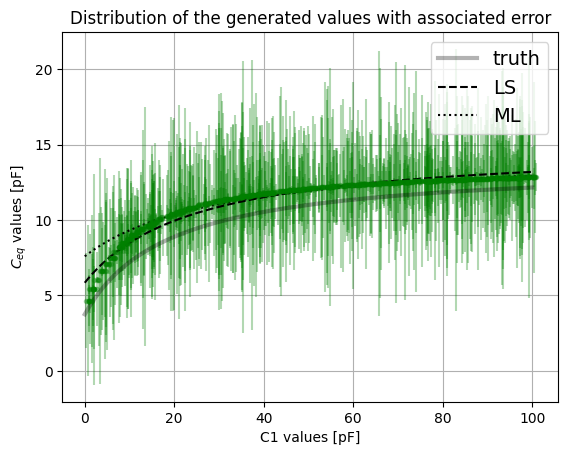

In [ ]:
def log_likelihood(theta, x, y, yerr):
    a, b = theta
    model = func(x, a, b)
    s2 = yerr ** 2 
    return -0.5 * np.sum((y - model) ** 2 / s2 + np.log(2*np.pi*s2))

# Reproducible results
np.random.seed(0)

#I redefine the data arrays
x, y, y_err = off_val[:,0], error_val[:,0], error_val[:,1]

# Initial guess for the parameters (made imperfect by some Gaussian noise)
initial = np.array([a_true, b_true]) + 0.1 * np.random.randn(2)

# Solve by minimization of -log-likelihood
soln = minimize(lambda *args: -log_likelihood(*args), initial, args=(x, y, y_err))

# Check whether it converged
print("Success status:", soln.success)
print(soln.message)

# Extract maximum likelihood parameter values
a_ml, b_ml = soln.x
print("Maximum likelihood estimates:")
print(f"m = {a_ml:.4f} (True: {a_true:.4f})")
print(f"q = {b_ml:.4f} (True: {b_true:.4f})")

# Plot everything we found so far
x_plot = np.linspace(0, 100, 2000)
plt.errorbar(x, y, yerr=y_err, fmt=".g", alpha=0.3, capsize=0)
plt.plot(x_plot,func(x_plot, a_true, b_true), "k", alpha=0.3, lw=3, label="truth")
plt.plot(x_plot, func(x_plot, popt[0], popt[1]), "--k", label="LS")
plt.plot(x_plot, func(x_plot, a_ml, b_ml), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlabel('C1 values [pF]')
plt.ylabel('$C_{eq}$ values [pF]')
plt.title("Distribution of the generated values with associated error")
plt.grid();

In [ ]:
def log_prior(theta):
    a, b = theta
    # Return a finite value if theta is in the parameter space region with support for the prior
    if 3 < a < 17 and 0.05 < b < 0.09:
        return 0.0
    # Otherwise return -infinity, basically a massive down-weight for the posterior
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    # If theta is outside the support for the prior, return -infinity
    if not np.isfinite(lp):
        return -np.inf
    # Otherwise return the logarithm of prior*likelihood, i.e. log_prior + log_likelihood
    return lp + log_likelihood(theta, x, y, yerr)

# The number of walkers
nwalkers = 32

# The dimensionality of the parameter space
ndim = 2

# The MCMC steps each walker needs to take
nmcmc = 5000

# Initial positions of the 32 walkers: we build this as ML position + noise
pos = soln.x + 1e-4 * np.random.randn(nwalkers, ndim)

# Run the sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, y_err))
sampler.run_mcmc(pos, nmcmc, progress=True); 

100%|██████████| 5000/5000 [00:02<00:00, 2423.25it/s]


[31.17434156 29.84933149]
(10432, 2)


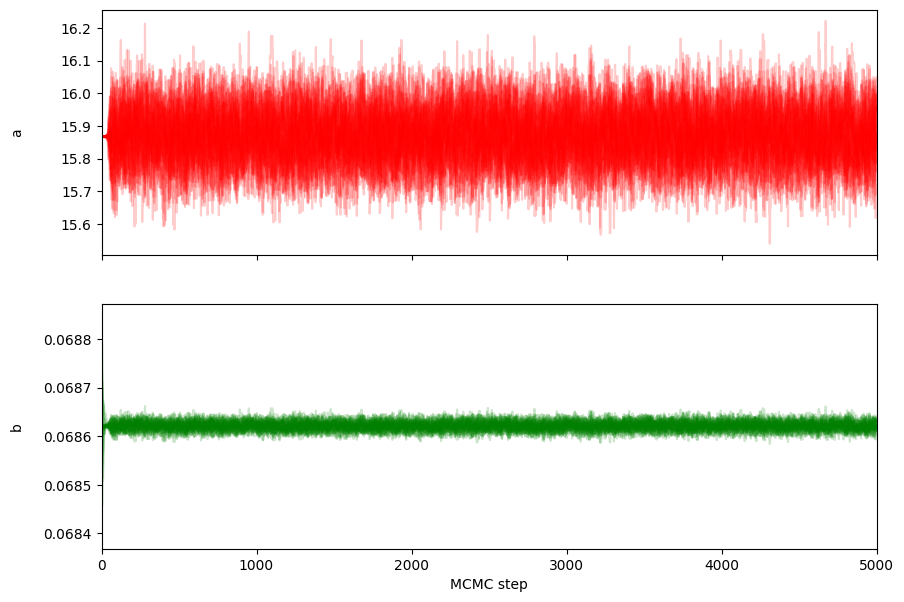

In [ ]:
#I plot the walker's paths for the two params
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b"]
col = ['r', 'g']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], col[i], alpha=0.2)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("MCMC step"); # The ; avoids an unwanted output to screen.
tau = sampler.get_autocorr_time() # I get the autocorrelation time.
print(tau)
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True) #Discard the first 100 values and take one value every 15 steps (since autocorrelation is 30)
print(flat_samples.shape)

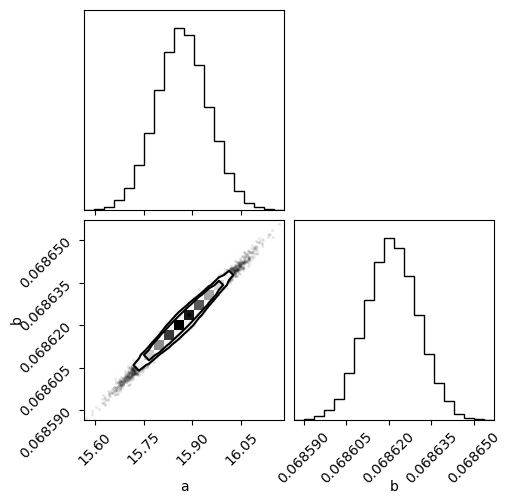

In [ ]:
import corner
#I do a corner plot, to give me an idea of what MCMC has done
fig = corner.corner(flat_samples, labels=labels, truths=[a_true, b_true])

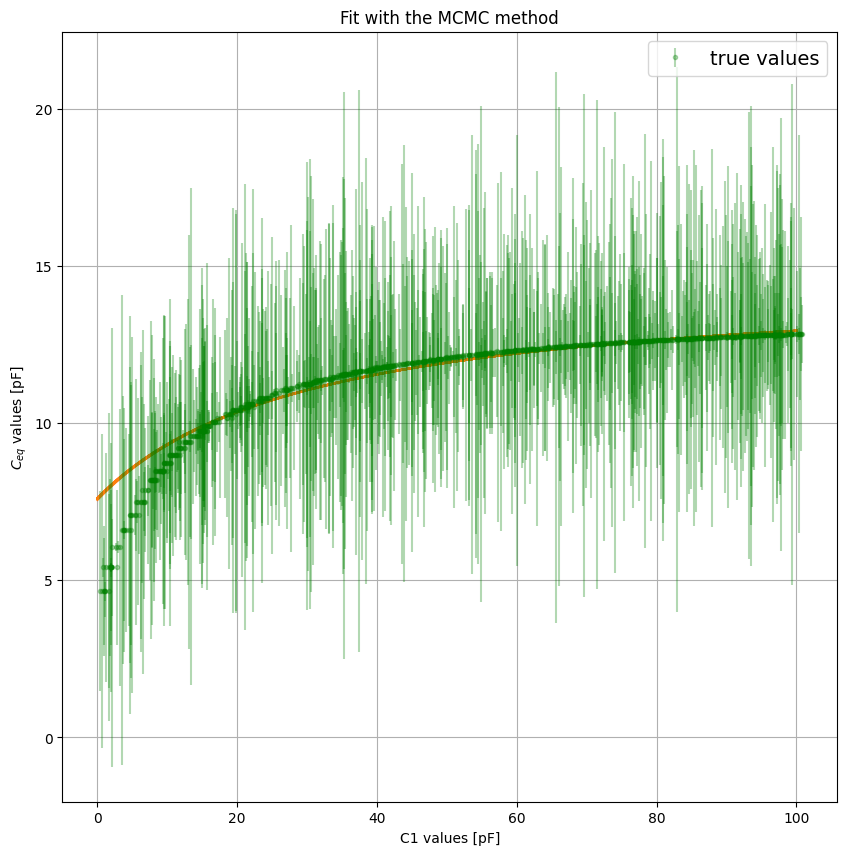

In [ ]:
fig = plt.figure(figsize=(10,10))

inds = np.random.randint(len(flat_samples), size=100)
for ind in inds: #I plot the fits with different a,b taken from flat_samples
    sample = flat_samples[ind]
    plt.plot(x_plot, func(x_plot, sample[0], sample[1]), "C1", alpha=0.15)

plt.errorbar(x, y, yerr=y_err, fmt=".g", capsize=0,linestyle='None', alpha=0.3, label='true values')

plt.legend(fontsize=14)
plt.xlabel('C1 values [pF]')
plt.ylabel('$C_{eq}$ values [pF]')
plt.title("Fit with the MCMC method")
plt.grid();

In [ ]:
from IPython.display import display, Math


#I display the results of the two parameters with MCMC method and their compatibility with true values.
msg = "\\mathrm{MCMC~results:}"
display(Math(msg))
txt = "\\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
labels2 = ["Compatibilità \\ a", "Compatibilità \\ b"]
txt2 = "\\mathrm{{{0}}} = {1:.3f}"
for i in range(ndim):
    ptile = np.percentile(flat_samples[:, i], [5, 50, 95])
    interval = np.diff(ptile)
    display(Math(txt.format(ptile[1], interval[0], interval[1], labels[i])))
    display(Math(txt2.format(labels2[i], abs(true_values[i]-ptile[1])/interval[0])))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The LS method seems to work better than MCMC, the reason may be that the model is incorrect.